# Small Examples for E-VQE

In [1]:
from pathlib import Path
import os
import sys

main_directory = Path(os.path.abspath("")).parent
sys.path.append(str(main_directory))

# 4 Qubit JSSP Sample

### Create a 4 qubit JSSP problem instance

In [2]:
from queasars.job_shop_scheduling.problem_instances import Machine, Operation, Job, JobShopSchedulingProblemInstance

machines = (Machine(name="m0"), Machine(name="m1"))

j0op1 = Operation(name="j0op0", machine=machines[0], processing_duration=1, job_name="j0")
j0op2 = Operation(name="j0op1", machine=machines[1], processing_duration=1, job_name="j0")
job0 = Job(name="j0", operations=(j0op1, j0op2))

j1op1 = Operation(name="j1op1", machine=machines[0], processing_duration=1, job_name="j1")
j1op2 = Operation(name="j1op2", machine=machines[1], processing_duration=1, job_name="j1")
job1 = Job(name="j1", operations=(j1op1, j1op2))

jssp_instance = JobShopSchedulingProblemInstance(name="2_jobs_2_machines_seed_121", machines=machines, jobs=(job0, job1))

### Visualize the created problem instance (optional)

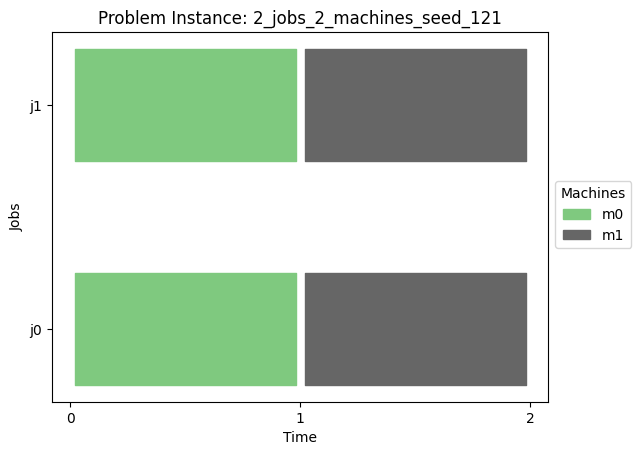

In [3]:
from queasars.job_shop_scheduling.visualization import plot_jssp_problem_instance_gantt

plot = plot_jssp_problem_instance_gantt(problem_instance=jssp_instance)

### Convert the problem instance to a Hamiltonian

In [4]:
from queasars.job_shop_scheduling.domain_wall_hamiltonian_encoder import JSSPDomainWallHamiltonianEncoder

# This encoder represents the configured JSSP instance as a Hamiltonian.
# Besides the penalties which are problem-dependent, the makespan_limit defines the maximum size of the time variables and hence influences the number of required qubits.
encoder = JSSPDomainWallHamiltonianEncoder(jssp_instance=jssp_instance, makespan_limit=3, max_opt_value=100, opt_all_operations_share=0.19, encoding_penalty=319, overlap_constraint_penalty=319, precedence_constraint_penalty=275)

print("needed qubits: ", encoder.n_qubits)

hamiltonian = encoder.get_problem_hamiltonian()

needed qubits:  4


### Setup the configuration for the EVQEMinimumEigensolver

Here we set up a minimal E-VQE configuration for testing the above defined very small JSSP optimization problem.

Notice that it uses some parameters for the E-VQE part which can be modified but we document only the relevant parameters
for changing the QC backend.

In [5]:
from concurrent.futures import ThreadPoolExecutor

from qiskit_aer.primitives import SamplerV2
from qiskit_algorithms.optimizers import SPSA

from queasars.circuit_evaluation.configured_primitives import ConfiguredSamplerV2
from queasars.minimum_eigensolvers.base.termination_criteria import BestIndividualRelativeChangeTolerance
from queasars.utility.spsa_termination import SPSATerminationChecker
from queasars.minimum_eigensolvers.evqe.evqe import EVQEMinimumEigensolverConfiguration

# The EVQEMinimumEigensolver needs at least a sampler and can also use an estimator.
# The Critical Value at Risk objective value can only be used when only using a sampler, hence we define one here.
# In case only a Qiskit backend (V2 primitive) is defined, one can use a generic BackendSamplerV2 to wrap it, e.g.
#
# from qiskit.primitives import BackendSamplerV2
# 
# sampler_primitive = ConfiguredSamplerV2(
#     sampler=BackendSamplerV2(backend=YOUR_BACKEND_HERE),
#     shots=1024,
# )
sampler_primitive = ConfiguredSamplerV2(
    sampler=SamplerV2(),
    shots=512,
)

# A Qiskit PassManager can be given to specify the transpilation process.
pass_manager = None

configuration = EVQEMinimumEigensolverConfiguration(
    configured_sampler=sampler_primitive,
    configured_estimator=None,
    pass_manager=pass_manager,
    distribution_alpha_tail=0.5,
    optimizer=SPSA(maxiter=33, perturbation=0.35, learning_rate=0.43, trust_region=True, last_avg=1, resamplings=1, termination_checker=SPSATerminationChecker(minimum_relative_change=0.01, allowed_consecutive_violations=2).termination_check),
    optimizer_n_circuit_evaluations=66,
    max_generations=None,
    max_circuit_evaluations=None,
    termination_criterion=BestIndividualRelativeChangeTolerance(minimum_relative_change=0.01, allowed_consecutive_violations=1),
    random_seed=None,
    population_size=10,
    n_initial_layers=2,
    randomize_initial_population_parameters=True,
    speciation_genetic_distance_threshold=1,
    use_tournament_selection=True,
    tournament_size=2,
    selection_alpha_penalty=0.15,
    selection_beta_penalty=0.02,
    parameter_search_probability=0.39,
    topological_search_probability=0.79,
    layer_removal_probability=0.02,
    parallel_executor=ThreadPoolExecutor(max_workers=1),
    mutually_exclusive_primitives=False,
)

## Setup the EVQEMinimumEigensolver

In [6]:
from queasars.minimum_eigensolvers.evqe.evqe import EVQEMinimumEigensolver

eigensolver = EVQEMinimumEigensolver(configuration=configuration)

## Solve the problem as posed in the Hamiltonian

In [7]:
import logging

logger = logging.getLogger("queasars.minimum_eigensolvers.base.evolving_ansatz_minimum_eigensolver")
handler = logging.StreamHandler()
logger.setLevel(logging.INFO)
logger.addHandler(handler)

result = eigensolver.compute_minimum_eigenvalue(operator=hamiltonian)
quasi_distribution = result.eigenstate.binary_probabilities()

Starting evolution!
Results for generation: 0
Current best expectation value: 63.500000
Current median expectation value: 284.822754
Current average expectation value: 287.286621
Results for generation: 1
Current best expectation value: 63.500000
Current median expectation value: 63.500000
Current average expectation value: 141.220703
Results for generation: 2
Current best expectation value: 63.500000
Current median expectation value: 63.500000
Current average expectation value: 63.500000


## Plot the distribution

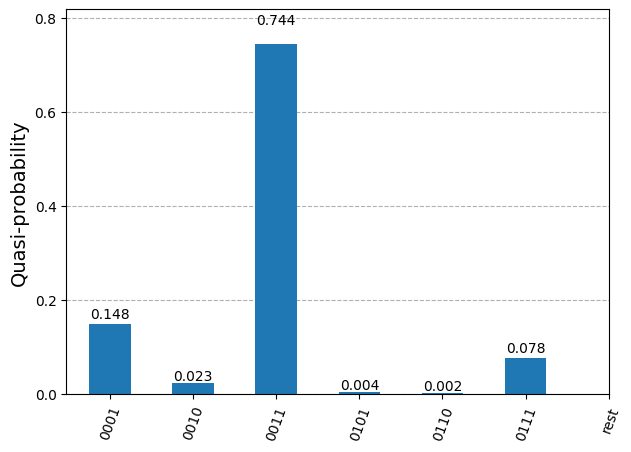

In [8]:
from qiskit.visualization import plot_distribution

plot_distribution(quasi_distribution, number_to_keep=10)

## Use the encoder to retrieve the solution

In [9]:
solutions = []
for bitstring, probability in quasi_distribution.items():
    if probability < 0.05:
        continue

    solution = encoder.translate_result_bitstring(bitstring=bitstring)

    print("probability: ", probability, "is valid: ", solution.is_valid)
    print(solution)
    if solution.is_valid:
        solutions.append(solution)

probability:  0.744140625 is valid:  True
2_jobs_2_machines_seed_121 solution with makespan 3
  j0:
    j0_j0op0(m0, 1) starts at: 1 and ends at: 2
    j0_j0op1(m1, 1) starts at: 2 and ends at: 3
  j1:
    j1_j1op1(m0, 1) starts at: 0 and ends at: 1
    j1_j1op2(m1, 1) starts at: 1 and ends at: 2

probability:  0.1484375 is valid:  False
2_jobs_2_machines_seed_121 solution with makespan None
  j0:
    j0_j0op0(m0, 1) starts at: 1 and ends at: 2
    j0_j0op1(m1, 1) starts at: 1 and ends at: 2
  j1:
    j1_j1op1(m0, 1) starts at: 0 and ends at: 1
    j1_j1op2(m1, 1) starts at: 1 and ends at: 2

probability:  0.078125 is valid:  False
2_jobs_2_machines_seed_121 solution with makespan None
  j0:
    j0_j0op0(m0, 1) starts at: 1 and ends at: 2
    j0_j0op1(m1, 1) starts at: 2 and ends at: 3
  j1:
    j1_j1op1(m0, 1) starts at: 1 and ends at: 2
    j1_j1op2(m1, 1) starts at: 1 and ends at: 2



## Visualize the result (optional)

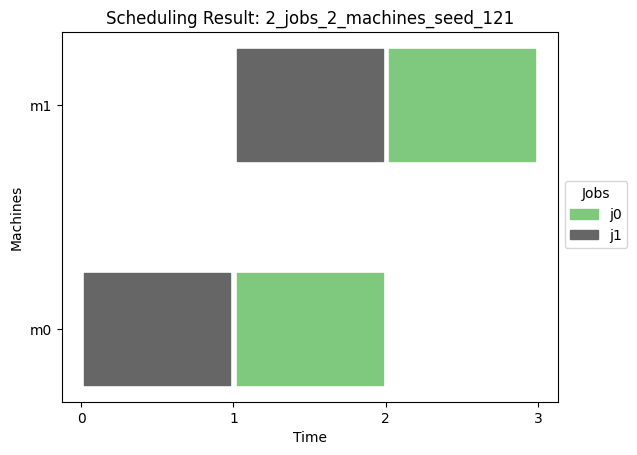

In [10]:
from queasars.job_shop_scheduling.visualization import plot_jssp_problem_solution_gantt

for solution in solutions:
    plot = plot_jssp_problem_solution_gantt(result=solution)

# 5 Qubit JSSP Sample

### Create a 5 qubit JSSP problem instance

In [29]:
from queasars.job_shop_scheduling.problem_instances import Machine, Operation, Job, JobShopSchedulingProblemInstance

machines = (Machine(name="m0"), Machine(name="m1"), Machine(name="m2"))

j0op1 = Operation(name="j0op1", machine=machines[0], processing_duration=1, job_name="j0")
j0op2 = Operation(name="j0op2", machine=machines[1], processing_duration=2, job_name="j0")
job0 = Job(name="j0", operations=(j0op1,j0op2))

j1op1 = Operation(name="j1op1", machine=machines[0], processing_duration=1, job_name="j1")
j1op2 = Operation(name="j1op2", machine=machines[1], processing_duration=1, job_name="j1")
j1op3 = Operation(name="j1op3", machine=machines[2], processing_duration=1, job_name="j1")
job1 = Job(name="j1", operations=(j1op1, j1op2, j1op3))

jssp_instance = JobShopSchedulingProblemInstance(name="2_jobs_2_machines_asymmetric", machines=machines, jobs=(job0, job1))

### Visualize the created problem instance (optional)

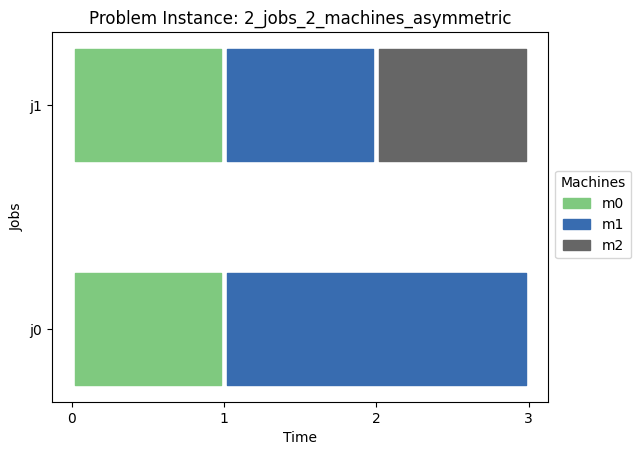

In [30]:
from queasars.job_shop_scheduling.visualization import plot_jssp_problem_instance_gantt

plot = plot_jssp_problem_instance_gantt(problem_instance=jssp_instance)

### Convert the problem instance to a Hamiltonian

In [31]:
from queasars.job_shop_scheduling.domain_wall_hamiltonian_encoder import JSSPDomainWallHamiltonianEncoder

# This encoder represents the configured JSSP instance as a Hamiltonian.
# Besides the penalties which are problem-dependent, the makespan_limit defines the maximum size of the time variables and hence influences the number of required qubits.
encoder = JSSPDomainWallHamiltonianEncoder(jssp_instance=jssp_instance, makespan_limit=4, max_opt_value=100, opt_all_operations_share=0.19, encoding_penalty=319, overlap_constraint_penalty=319, precedence_constraint_penalty=275)

print("needed qubits: ", encoder.n_qubits)

hamiltonian = encoder.get_problem_hamiltonian()

needed qubits:  5


### Setup the configuration for the EVQEMinimumEigensolver

Here we set up a minimal E-VQE configuration for testing the above defined very small JSSP optimization problem.

Notice that it uses some parameters for the E-VQE part which can be modified but we document only the relevant parameters
for changing the QC backend.

In [32]:
from concurrent.futures import ThreadPoolExecutor

from qiskit_aer.primitives import SamplerV2
from qiskit_algorithms.optimizers import SPSA

from queasars.circuit_evaluation.configured_primitives import ConfiguredSamplerV2
from queasars.minimum_eigensolvers.base.termination_criteria import BestIndividualRelativeChangeTolerance
from queasars.utility.spsa_termination import SPSATerminationChecker
from queasars.minimum_eigensolvers.evqe.evqe import EVQEMinimumEigensolverConfiguration

# The EVQEMinimumEigensolver needs at least a sampler and can also use an estimator.
# The Critical Value at Risk objective value can only be used when only using a sampler, hence we define one here.
# In case only a Qiskit backend (V2 primitive) is defined, one can use a generic BackendSamplerV2 to wrap it, e.g.
#
# from qiskit.primitives import BackendSamplerV2
# 
# sampler_primitive = ConfiguredSamplerV2(
#     sampler=BackendSamplerV2(backend=YOUR_BACKEND_HERE),
#     shots=1024,
# )
sampler_primitive = ConfiguredSamplerV2(
    sampler=SamplerV2(),
    shots=512,
)

# A Qiskit PassManager can be given to specify the transpilation process.
pass_manager = None

configuration = EVQEMinimumEigensolverConfiguration(
    configured_sampler=sampler_primitive,
    configured_estimator=None,
    pass_manager=pass_manager,
    distribution_alpha_tail=0.5,
    optimizer=SPSA(maxiter=33, perturbation=0.35, learning_rate=0.43, trust_region=True, last_avg=1, resamplings=1, termination_checker=SPSATerminationChecker(minimum_relative_change=0.01, allowed_consecutive_violations=2).termination_check),
    optimizer_n_circuit_evaluations=66,
    max_generations=None,
    max_circuit_evaluations=None,
    termination_criterion=BestIndividualRelativeChangeTolerance(minimum_relative_change=0.01, allowed_consecutive_violations=1),
    random_seed=None,
    population_size=10,
    n_initial_layers=2,
    randomize_initial_population_parameters=True,
    speciation_genetic_distance_threshold=1,
    use_tournament_selection=True,
    tournament_size=2,
    selection_alpha_penalty=0.15,
    selection_beta_penalty=0.02,
    parameter_search_probability=0.39,
    topological_search_probability=0.79,
    layer_removal_probability=0.02,
    parallel_executor=ThreadPoolExecutor(max_workers=1),
    mutually_exclusive_primitives=False,
)

## Setup the EVQEMinimumEigensolver

In [33]:
from queasars.minimum_eigensolvers.evqe.evqe import EVQEMinimumEigensolver

eigensolver = EVQEMinimumEigensolver(configuration=configuration)

## Solve the problem as posed in the Hamiltonian

In [34]:
import logging

logger = logging.getLogger("queasars.minimum_eigensolvers.base.evolving_ansatz_minimum_eigensolver")
handler = logging.StreamHandler()
logger.setLevel(logging.INFO)
logger.addHandler(handler)

result = eigensolver.compute_minimum_eigenvalue(operator=hamiltonian)
quasi_distribution = result.eigenstate.binary_probabilities()

Starting evolution!
Starting evolution!
Results for generation: 0
Results for generation: 0
Current best expectation value: 200.183594
Current best expectation value: 200.183594
Current median expectation value: 496.491016
Current median expectation value: 496.491016
Current average expectation value: 502.607500
Current average expectation value: 502.607500
Results for generation: 1
Results for generation: 1
Current best expectation value: 61.600000
Current best expectation value: 61.600000
Current median expectation value: 329.080469
Current median expectation value: 329.080469
Current average expectation value: 277.907266
Current average expectation value: 277.907266
Results for generation: 2
Results for generation: 2
Current best expectation value: 61.600000
Current best expectation value: 61.600000
Current median expectation value: 61.600000
Current median expectation value: 61.600000
Current average expectation value: 143.482187
Current average expectation value: 143.482187
Result

## Plot the distribution

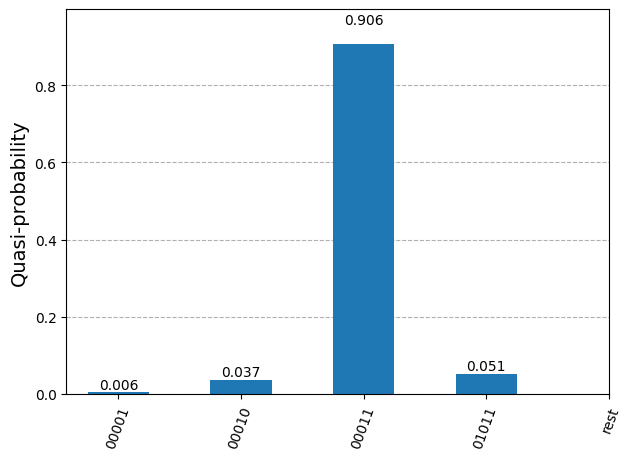

In [35]:
from qiskit.visualization import plot_distribution

plot_distribution(quasi_distribution, number_to_keep=10)

## Use the encoder to retrieve the solution

In [36]:
solutions = []
for bitstring, probability in quasi_distribution.items():
    if probability < 0.05:
        continue

    solution = encoder.translate_result_bitstring(bitstring=bitstring)

    print("probability: ", probability, "is valid: ", solution.is_valid)
    print(solution)
    if solution.is_valid:
        solutions.append(solution)

probability:  0.90625 is valid:  True
2_jobs_2_machines_asymmetric solution with makespan 4
  j0:
    j0_j0op1(m0, 1) starts at: 1 and ends at: 2
    j0_j0op2(m1, 2) starts at: 2 and ends at: 4
  j1:
    j1_j1op1(m0, 1) starts at: 0 and ends at: 1
    j1_j1op2(m1, 1) starts at: 1 and ends at: 2
    j1_j1op3(m2, 1) starts at: 2 and ends at: 3

probability:  0.05078125 is valid:  False
2_jobs_2_machines_asymmetric solution with makespan None
  j0:
    j0_j0op1(m0, 1) starts at: 1 and ends at: 2
    j0_j0op2(m1, 2) starts at: 2 and ends at: 4
  j1:
    j1_j1op1(m0, 1) starts at: 0 and ends at: 1
    j1_j1op2(m1, 1) starts at: 2 and ends at: 3
    j1_j1op3(m2, 1) starts at: 2 and ends at: 3



## Visualize the result (optional)

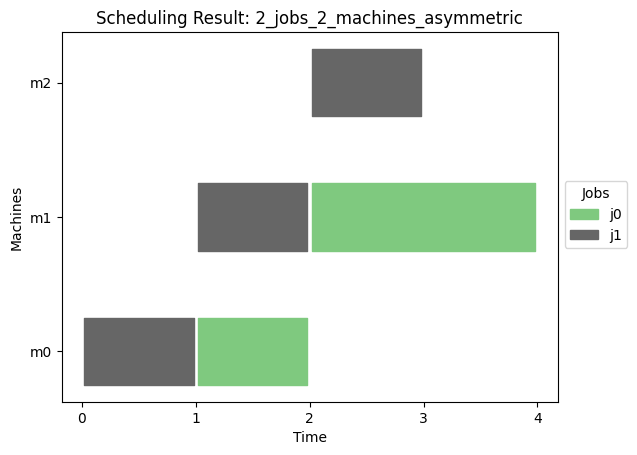

In [37]:
from queasars.job_shop_scheduling.visualization import plot_jssp_problem_solution_gantt

for solution in solutions:
    plot = plot_jssp_problem_solution_gantt(result=solution)